# Hazel Log Analysis

This notebook analyzes student interaction logs from Hazel submissions to understand proof strategies, exploration patterns, and learning behaviors.

## Research Questions

1. What kind of ways do students go wrong?
2. Exploration paths: lots of things you have to do and undo
3. Wall-clock time analysis
4. Do students do stuff before doing any induction?
5. Stepper usage patterns
6. Random clicking indicators
7. When do students do the IH?
8. What sort of terms do students attempt to do induction over?
9. Do they prove the lemma before or after the proof that uses it?


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
import sys
import importlib

# Import our custom modules
from parser import HazelLogParser
from analysis_utils import (
    calculate_time_diffs, get_time_statistics, identify_rapid_actions,
    segment_by_breaks, analyze_session_segments, identify_activity_bursts
)

from path_extractor import (
    extract_action_sequences, identify_exploration_paths,
    identify_focused_paths, identify_navigation_paths,
    track_proof_progression, find_induction_patterns, summarize_paths,
    analyze_induction_timing_patterns, track_induction_progression
)

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Test that all functions are available
print("Testing function availability...")

# Test basic functions
try:
    result = extract_action_sequences
    print("✅ extract_action_sequences available")
except NameError:
    print("❌ extract_action_sequences not available")

try:
    result = find_induction_patterns
    print("✅ find_induction_patterns available")
except NameError:
    print("❌ find_induction_patterns not available")

try:
    result = analyze_induction_timing_patterns
    print("✅ analyze_induction_timing_patterns available")
except NameError:
    print("❌ analyze_induction_timing_patterns not available")

try:
    result = track_induction_progression
    print("✅ track_induction_progression available")
except NameError:
    print("❌ track_induction_progression not available")

print("\n🎉 All functions tested!")


Testing function availability...
✅ extract_action_sequences available
✅ find_induction_patterns available
✅ analyze_induction_timing_patterns available
✅ track_induction_progression available

🎉 All functions tested!


## Load and Parse Data


In [3]:
# Initialize parser
parser = HazelLogParser()

# Load multiple log files for comparison - using random files from a2_logs
log_files = [
    "a2_logs/submission_349549369.json",
    "a2_logs/submission_350032314.json",
    "a2_logs/submission_349944161.json",    
]

# Load all log files
all_logs = {}
for filepath in log_files:
    try:
        df = parser.parse_file(filepath)
        all_logs[filepath] = df
        print(f"Loaded {filepath}: {len(df)} log entries")
        print(f"  Time range: {df['datetime'].min()} to {df['datetime'].max()}")
        print(f"  Duration: {(df['datetime'].max() - df['datetime'].min()).total_seconds():.1f} seconds")
    except Exception as e:
        print(f"Error loading {filepath}: {e}")

# Use the first successfully loaded log for the main analysis
if all_logs:
    main_log_file = list(all_logs.keys())[-1]
    df = all_logs[main_log_file]
    print(f"\nUsing {main_log_file} for main analysis")
else:
    print("No log files could be loaded!")


Loaded a2_logs/submission_349549369.json: 10847 log entries
  Time range: 2025-09-07 07:32:02.363000 to 2025-09-21 03:42:17.351000
  Duration: 1195815.0 seconds
Loaded a2_logs/submission_350032314.json: 7210 log entries
  Time range: 2025-09-10 13:42:40.497000 to 2025-09-22 14:45:02.365000
  Duration: 1040541.9 seconds
Loaded a2_logs/submission_349944161.json: 23169 log entries
  Time range: 2025-09-07 11:01:00.171000 to 2025-09-22 11:52:24.056000
  Duration: 1299083.9 seconds

Using a2_logs/submission_349944161.json for main analysis


In [4]:
df[:10]

,timestamp,datetime,action_raw,type
0,1.758241e+12,2025-09-18 17:10:31.534,"Globals(FinishImportAll(""{\""settings\"":\""((cap...","Globals(FinishImportAll(""{\""settings\"":\""((cap..."
1,1.757268e+12,2025-09-07 11:01:00.171,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...
2,1.757268e+12,2025-09-07 11:01:00.404,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...
3,1.757268e+12,2025-09-07 11:01:00.620,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...
4,1.757268e+12,2025-09-07 11:01:00.669,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...
5,1.757268e+12,2025-09-07 11:01:00.736,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...
6,1.757357e+12,2025-09-08 11:50:12.283,Editors(SwitchMode Exercises,Editors(SwitchMode Exercises
7,1.757357e+12,2025-09-08 11:50:20.294,MakeActive(Exercises(Cell YourTestsTesting Mai...,MakeActive(Exercises(Cell YourTestsTesting Mai...
8,1.757357e+12,2025-09-08 11:50:20.317,Editors(Exercises(Exercise(Editor YourTestsTes...,Editors(Exercises(Exercise(Editor YourTestsTes...
9,1.757357e+12,2025-09-08 11:50:20.322,Editors(Exercises(Exercise(Editor YourTestsTes...,Editors(Exercises(Exercise(Editor YourTestsTes...


In [5]:
df.action_raw.value_counts()

action_raw
MakeActive(Exercises(Cell YourImpl MainEditor                                                                                                                                                                                                                    1396
Editors(Exercises(Exercise(Editor YourImpl(MainEditor(Perform(Destruct Left                                                                                                                                                                                       858
MakeActive(Scratch(Cell MainEditor                                                                                                                                                                                                                                712
Editors(Scratch(CellAction(MainEditor(Perform(Destruct Left                                                                                                                                                

In [6]:
df["action_target"] = df.action_raw.apply(lambda s: s.split("(")[0])
df["action_second"] = df.action_raw.apply(lambda s: s.split("(")[1])
df

,timestamp,datetime,action_raw,type,action_target,action_second
0,1.758241e+12,2025-09-18 17:10:31.534,"Globals(FinishImportAll(""{\""settings\"":\""((cap...","Globals(FinishImportAll(""{\""settings\"":\""((cap...",Globals,FinishImportAll
1,1.757268e+12,2025-09-07 11:01:00.171,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors,Tutorial
2,1.757268e+12,2025-09-07 11:01:00.404,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors,Tutorial
3,1.757268e+12,2025-09-07 11:01:00.620,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors,Tutorial
4,1.757268e+12,2025-09-07 11:01:00.669,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors,Tutorial
...,...,...,...,...,...,...
23164,1.758567e+12,2025-09-22 11:52:20.171,Editors(Exercises(SwitchExercise 2,Editors(Exercises(SwitchExercise 2,Editors,Exercises
23165,1.758567e+12,2025-09-22 11:52:20.921,Editors(Exercises(SwitchExercise 0,Editors(Exercises(SwitchExercise 0,Editors,Exercises
23166,1.758567e+12,2025-09-22 11:52:23.987,MakeActive(Exercises(Implementation(Cell YourT...,MakeActive(Exercises(Implementation(Cell YourT...,MakeActive,Exercises
23167,1.758567e+12,2025-09-22 11:52:24.047,Editors(Exercises(Exercise(Editor YourTestsTes...,Editors(Exercises(Exercise(Editor YourTestsTes...,Editors,Exercises


## Larger actions:

`Perform(Destruct Left`: backspace
`Perform(Select(Resize`: highlight text

In [ ]:
def trim_unwanted_actions(df):
    # Define substrings that indicate rows to remove
    excludes = [
        "MakeActive",
        "Select(Resize", # highlight text
        "Perform(Destruct Left", # backspace
        "Perform(Move(", # move cursor
        "Perform(Insert", # typing
        # "SwitchExercise",
        # "SwitchMode",
        # "FinishImportAll",
        # "SetHighlight",
        # "Globals(Set(ExplainThis",
    ]
    # Remove rows where action_raw starts with or contains any excluded substring
    mask = ~df["action_raw"].str.startswith(excludes[0])
    for substr in excludes[1:]:
        mask &= ~df["action_raw"].str.contains(substr, regex=False)
    return df[mask]

df_no_active = trim_unwanted_actions(df)
df_no_active

,timestamp,datetime,action_raw,type,action_target,action_second
0,1.758241e+12,2025-09-18 17:10:31.534,"Globals(FinishImportAll(""{\""settings\"":\""((cap...","Globals(FinishImportAll(""{\""settings\"":\""((cap...",Globals,FinishImportAll
6,1.757357e+12,2025-09-08 11:50:12.283,Editors(SwitchMode Exercises,Editors(SwitchMode Exercises,Editors,SwitchMode Exercises
66,1.757358e+12,2025-09-08 11:52:51.378,Editors(Exercises(Exercise(Editor YourImpl(Mai...,Editors(Exercises(Exercise(Editor YourImpl(Mai...,Editors,Exercises
188,1.757358e+12,2025-09-08 11:53:41.709,Editors(Exercises(Exercise(Editor YourImpl(Mai...,Editors(Exercises(Exercise(Editor YourImpl(Mai...,Editors,Exercises
282,1.757358e+12,2025-09-08 11:54:14.487,Editors(Exercises(Exercise(Editor YourImpl(Res...,Editors(Exercises(Exercise(Editor YourImpl(Res...,Editors,Exercises
...,...,...,...,...,...,...
23161,1.758567e+12,2025-09-22 11:52:15.537,Editors(Exercises(SwitchExercise 2,Editors(Exercises(SwitchExercise 2,Editors,Exercises
23162,1.758567e+12,2025-09-22 11:52:16.659,Editors(Exercises(SwitchExercise 0,Editors(Exercises(SwitchExercise 0,Editors,Exercises
23163,1.758567e+12,2025-09-22 11:52:17.088,Editors(Exercises(SwitchExercise 1,Editors(Exercises(SwitchExercise 1,Editors,Exercises
23164,1.758567e+12,2025-09-22 11:52:20.171,Editors(Exercises(SwitchExercise 2,Editors(Exercises(SwitchExercise 2,Editors,Exercises


In [31]:
exclude_keywords = ["Editors", 'Exercises', "Exercise", 'Editor', 'Theorem', 'ResultAction', 'TheoremsAction', 'TheoremUpdate']
def remove_keywords(s):
    s_items = s.split("(")
    s_items = [item for item in s_items if not any(keyword in item for keyword in exclude_keywords)]
    return "(".join(s_items)
df_no_active.action_raw.apply(remove_keywords).value_counts()

action_raw
                                                                                                                                                                                      242
Select(Resize(Point((row 0                                                                                                                                                             72
Perform(Select(Smart 2                                                                                                                                                                 62
StepKindAction(InductionStep(CaseUpdate 1(StepUpdate(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(Select(Resize(Point((row 0     49
Scratch(CellAction                                                                                                                                                                     40
                                                           

In [27]:
df_no_active.action_raw.value_counts()

action_raw
Editors(Exercises(Exercise(Editor YourImpl(MainEditor(Perform(Destruct Left                                                                                                         858
Editors(Scratch(CellAction(MainEditor(Perform(Destruct Left                                                                                                                         563
Editors(Scratch(CellAction(MainEditor(Perform(Select(Resize(Point((row 4                                                                                                            541
Editors(Exercises(Exercise(Editor YourImpl(MainEditor(Perform(Select(Resize(Point((row 3                                                                                            474
Editors(Exercises(Exercise(Editor YourImpl(MainEditor(Perform(Insert\\\" \\\"                                                                                                       368
                                                                     

In [4]:
file = "a2_logs/submission_349351711.json"
file = "a2_logs/submission_350032314.json"
file = "a2_logs/submission_349944161.json"
with open(file, 'r') as f:
    d = json.load(f)

In [5]:
d.keys()

dict_keys(['settings', 'explainThisModel', 'scratch', 'tutorial', 'exercise', 'documentation', 'log'])

In [6]:
[len(item) for item in d.values()]

[685, 45, 18002, 3149, 1201501, 115, 3659196]

In [7]:
print(d["log"][:1000])

((1758240631534(Globals(FinishImportAll("{\"settings\":\"((captions true)(secondary_icons false)(core((statics true)(elaborate false)(assist true)(dynamics true)(flip_animations true)(evaluation((show_case_clauses true)(show_fn_bodies false)(show_fixpoints false)(show_ascription_steps false)(show_lookup_steps false)(show_stepper_filters false)(stepper_history true)(show_settings false)(show_hidden_steps false)(enable_proof false)))))(async_evaluation false)(context_inspector false)(instructor_mode false)(benchmark false)(explainThis((show true)(show_feedback false)(highlight NoHighlight)))(assistant((mode CodeSuggestion)(ongoing_chat false)(show_history false)(show_api_key false)))(sidebar((show true)(panel LanguageDocumentation))))\",\"explainThisModel\":\"((specificity_open false)(forms())(groups()))\",\"scratch\":\"(0((\\\"Scratchpad 1\\\"(((editor((zipper\\\"((selection((focus Left)(content())(mode Normal)))(relatives((siblings(((Tile((id ff528093-96d8-48c8-abf1-81ad6b8a287c)(label

In [22]:
def prettify_log(log):
    return log.replace('\\"', '"').replace(") (", ")\n(")
print(prettify_log(d["log"][:10000]))

((1757536908190 Start)
(1757536960497(Editors(SwitchMode Scratch)))
(1757536966434(Editors(SwitchMode Tutorial)))
(1757537042000(Editors(Tutorial(Tutorial(Editor YourImpl(MainEditor(Perform(Insert 2))))))))
(1757537042558(Editors(Tutorial(Tutorial(Editor YourImpl(MainEditor(Perform(Insert" "))))))))
(1757537043555(Editors(Tutorial(Tutorial(Editor YourImpl(MainEditor(Perform(Insert +))))))))
(1757537043890(Editors(Tutorial(Tutorial(Editor YourImpl(MainEditor(Perform(Insert" "))))))))
(1757537044088(Editors(Tutorial(Tutorial(Editor YourImpl(MainEditor(Perform(Insert 2))))))))
(1757537047805(Editors(Tutorial(Tutorial MoveToNextExercise))))
(1757537054645(Editors(SwitchMode Exercises)))
(1757537136835(MakeActive(Exercises(Cell YourImpl MainEditor))))
(1757537136899(Editors(Exercises(Exercise(Editor YourImpl(MainEditor(Perform(Move(Point((row 1)(col 9)))))))))))
(1757537136963(Editors(Exercises(Exercise(Editor YourImpl(MainEditor(Perform(Select(Resize(Point((row 1)(col 9))))))))))))
(175753

In [23]:
df

,timestamp,datetime,action_raw,type
0,1.757537e+12,2025-09-10 16:42:40.497,Editors(SwitchMode Scratch,Editors(SwitchMode Scratch
1,1.757537e+12,2025-09-10 16:42:46.434,Editors(SwitchMode Tutorial,Editors(SwitchMode Tutorial
2,1.757537e+12,2025-09-10 16:44:02.000,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...
3,1.757537e+12,2025-09-10 16:44:02.558,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...
4,1.757537e+12,2025-09-10 16:44:03.555,Editors(Tutorial(Tutorial(Editor YourImpl(Main...,Editors(Tutorial(Tutorial(Editor YourImpl(Main...
...,...,...,...,...
7205,1.758577e+12,2025-09-22 17:44:21.786,MakeActive(Exercises(TheoremExercise(Theorem M...,MakeActive(Exercises(TheoremExercise(Theorem M...
7206,1.758577e+12,2025-09-22 17:44:21.810,Editors(Exercises(TheoremExercise(Theorem(Main...,Editors(Exercises(TheoremExercise(Theorem(Main...
7207,1.758577e+12,2025-09-22 17:44:21.822,Editors(Exercises(TheoremExercise(Theorem(Main...,Editors(Exercises(TheoremExercise(Theorem(Main...
7208,1.758578e+12,2025-09-22 17:45:01.857,Editors(Exercises(SwitchExercise 1,Editors(Exercises(SwitchExercise 1


## Time Analysis

Using utilities from `analysis_utils.py`


In [25]:
# Get comprehensive time statistics
time_stats = get_time_statistics(df)

print("=== TIME STATISTICS ===")
print(f"Total actions: {time_stats['total_actions']}")
print(f"Session duration: {time_stats['total_duration_seconds']:.1f} seconds")
print(f"Mean time between actions: {time_stats['mean_time_between_actions']:.2f}s")
print(f"Median time between actions: {time_stats['median_time_between_actions']:.2f}s")
print(f"Std dev: {time_stats['std_time_between_actions']:.2f}s")
print(f"95th percentile: {time_stats['percentile_95']:.2f}s")


=== TIME STATISTICS ===
Total actions: 10847
Session duration: 1195815.0 seconds
Mean time between actions: 110.25s
Median time between actions: 0.18s
Std dev: 8981.59s
95th percentile: 3.42s


In [26]:
# Identify rapid actions (potential random clicking)
rapid_actions, rapid_sequences = identify_rapid_actions(df, threshold=0.1)

print(f"\n=== RAPID ACTION ANALYSIS ===")
print(f"Rapid actions: {rapid_actions.sum()} out of {len(rapid_actions)}")
print(f"Percentage: {rapid_actions.sum() / len(rapid_actions) * 100:.1f}%")
print(f"Rapid sequences found: {len(rapid_sequences)}")

if rapid_sequences:
    seq_lengths = [len(seq) for seq in rapid_sequences]
    print(f"Sequence lengths: min={min(seq_lengths)}, max={max(seq_lengths)}, mean={np.mean(seq_lengths):.1f}")



=== RAPID ACTION ANALYSIS ===
Rapid actions: 3217 out of 10846
Percentage: 29.7%
Rapid sequences found: 259
Sequence lengths: min=2, max=60, mean=8.8


In [27]:
# Analyze session segments
segments = analyze_session_segments(df, break_threshold=10.0)

print(f"\n=== SESSION SEGMENTS ===")
print(f"Total segments: {len(segments)}")

for seg in segments[:5]:  # Show first 5 segments
    print(f"\nSegment {seg['segment_id']}:")
    print(f"  Actions: {seg['action_count']}, Duration: {seg['duration_seconds']:.1f}s")
    print(f"  Actions/second: {seg['actions_per_second']:.2f}")
    print(f"  Top action: {seg['top_action']}")



=== SESSION SEGMENTS ===
Total segments: 242

Segment 0:
  Actions: 1, Duration: 0.0s
  Actions/second: 0.00
  Top action: Editors(SwitchMode Exercises

Segment 1:
  Actions: 1, Duration: 0.0s
  Actions/second: 0.00
  Top action: Editors(SwitchMode Tutorial

Segment 2:
  Actions: 2, Duration: 9.7s
  Actions/second: 0.21
  Top action: Editors(SwitchMode Documentation

Segment 3:
  Actions: 32, Duration: 13.0s
  Actions/second: 2.46
  Top action: Editors(Tutorial(Tutorial(Editor YourImpl(MainEditor(Perform(Destruct Left

Segment 4:
  Actions: 28, Duration: 5.9s
  Actions/second: 4.71
  Top action: Editors(Tutorial(Tutorial(Editor YourImpl(MainEditor(Perform(Insert" "


## Path Extraction and Analysis

Using utilities from `path_extractor.py` to analyze sequences of operations


In [28]:
# Extract all action sequences
paths = extract_action_sequences(df)

print("=== PATH EXTRACTION ===")
print(f"Total paths extracted: {len(paths)}")

# Summarize paths
path_summary = summarize_paths(paths)
print(f"\nPath Summary:")
for key, value in path_summary.items():
    print(f"  {key}: {value}")


Ignored 4780 non-meaningful actions (4780/10847 = 44.1%)
=== PATH EXTRACTION ===
Total paths extracted: 135

Path Summary:
  total_paths: 135
  path_types: {'linear': 86, 'rapid': 37, 'focused': 11, 'navigation': 1}
  average_length: 44.94074074074074
  average_duration: 1975.3853259259256
  total_backtracks: 0
  paths_with_backtracks: 0


In [29]:
# Identify exploration paths (undo/redo patterns)
exploration_paths = identify_exploration_paths(df)

print(f"\n=== EXPLORATION PATHS ===")
print(f"Found {len(exploration_paths)} exploration paths")

for i, path in enumerate(exploration_paths[:3]):  # Show first 3
    path_dict = path.to_dict()
    print(f"\nExploration Path {i+1}:")
    print(f"  Length: {path_dict['length']} actions")
    print(f"  Duration: {path_dict['duration_seconds']:.1f}s")
    print(f"  Backtracks: {path_dict['backtrack_count']}")


Ignored 4780 non-meaningful actions (4780/10847 = 44.1%)

=== EXPLORATION PATHS ===
Found 115 exploration paths

Exploration Path 1:
  Length: 28 actions
  Duration: 47.3s
  Backtracks: 0

Exploration Path 2:
  Length: 8 actions
  Duration: 53.9s
  Backtracks: 0

Exploration Path 3:
  Length: 4 actions
  Duration: 59.6s
  Backtracks: 0


In [30]:
# Track proof progression
proof_progression = track_proof_progression(df)

print(f"\n=== PROOF PROGRESSION ===")
print(f"Action types:")
for action_type, count in proof_progression['action_types'].items():
    if count > 0:
        print(f"  {action_type}: {count}")

if proof_progression['first_induction_action']:
    print(f"\nFirst induction at: {proof_progression['first_induction_action']['timestamp']}")
    print(f"  Action index: {proof_progression['first_induction_action']['action_index']}")

if proof_progression['first_hypothesis_use']:
    print(f"\nFirst hypothesis use at: {proof_progression['first_hypothesis_use']['timestamp']}")
    print(f"  Action index: {proof_progression['first_hypothesis_use']['action_index']}")



=== PROOF PROGRESSION ===
Action types:
  induction: 1072
  case_analysis: 1061
  hypothesis: 4

First induction at: 2025-09-19 06:13:50.358000
  Action index: 6022

First hypothesis use at: 2025-09-20 07:49:05.476000
  Action index: 6217


In [31]:
# Analyze induction patterns
induction_analysis = find_induction_patterns(df)

print(f"\n=== ENHANCED INDUCTION PATTERNS ===")
print(f"Total induction actions: {induction_analysis['total_induction_actions']}")

if induction_analysis['time_to_first_induction'] is not None:
    print(f"Time to first induction: {induction_analysis['time_to_first_induction']:.1f}s")

if induction_analysis['average_time_between_inductions'] is not None:
    print(f"Average time between inductions: {induction_analysis['average_time_between_inductions']:.1f}s")

# Show induction targets analysis
targets = induction_analysis['induction_targets']
print(f"\nInduction Type Distribution:")
for ind_type, count in targets['induction_type_distribution'].items():
    print(f"  {ind_type}: {count}")

if targets['target_term_distribution']:
    print(f"\nTarget Term Distribution:")
    for term, count in targets['target_term_distribution'].items():
        print(f"  {term}: {count}")

# Show success patterns
success = induction_analysis['induction_success_patterns']
print(f"\nInduction Success Analysis:")
print(f"  Total inductions: {success['total_inductions']}")
print(f"  Successful inductions: {success['successful_inductions']}")
print(f"  Success rate: {success['success_rate']:.2%}")

# Show detailed induction events
if induction_analysis['induction_events']:
    print(f"\nDetailed Induction Events:")
    for i, event in enumerate(induction_analysis['induction_events'][:3]):  # Show first 3
        context = event.get('context', {})
        print(f"\nInduction {i+1}:")
        print(f"  Time: {event['timestamp']}")
        print(f"  Type: {context.get('induction_type', 'unknown')}")
        print(f"  Target: {context.get('target_term', 'unknown')}")
        print(f"  Has hypothesis: {context.get('has_hypothesis', False)}")
        print(f"  Has base case: {context.get('has_base_case', False)}")
        print(f"  Has step case: {context.get('has_step_case', False)}")



=== ENHANCED INDUCTION PATTERNS ===
Total induction actions: 818
Time to first induction: 1021308.0s
Average time between inductions: 213.6s

Induction Type Distribution:
  add_induction: 12
  modify_case: 806

Induction Success Analysis:
  Total inductions: 817
  Successful inductions: 807
  Success rate: 98.78%

Detailed Induction Events:

Induction 1:
  Time: 2025-09-19 06:13:50.358000
  Type: add_induction
  Target: None
  Has hypothesis: False
  Has base case: False
  Has step case: False

Induction 2:
  Time: 2025-09-19 06:14:53.087000
  Type: add_induction
  Target: None
  Has hypothesis: False
  Has base case: False
  Has step case: False

Induction 3:
  Time: 2025-09-20 07:32:00.543000
  Type: add_induction
  Target: None
  Has hypothesis: False
  Has base case: False
  Has step case: False


In [32]:
# Analyze induction timing patterns
timing_analysis = analyze_induction_timing_patterns(df)

print(f"\n=== INDUCTION TIMING PATTERNS ===")
print(f"Total inductions: {timing_analysis['total_inductions']}")

if timing_analysis['total_inductions'] > 0:
    timing_dist = timing_analysis['timing_distribution']
    print(f"\nTiming Distribution:")
    print(f"  Early induction (first 25%): {timing_dist['early_induction']}")
    print(f"  Mid induction (middle 50%): {timing_dist['mid_induction']}")
    print(f"  Late induction (last 25%): {timing_dist['late_induction']}")
    
    # Show pre/post induction actions
    pre_actions = timing_analysis['pre_induction_action_counts']
    post_actions = timing_analysis['post_induction_action_counts']
    
    print(f"\nMost Common Actions Before Induction:")
    for action, count in sorted(pre_actions.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {action}: {count}")
    
    print(f"\nMost Common Actions After Induction:")
    for action, count in sorted(post_actions.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {action}: {count}")
else:
    print("No induction events found in this session.")



=== INDUCTION TIMING PATTERNS ===
Total inductions: 818

Timing Distribution:
  Early induction (first 25%): 0
  Mid induction (middle 50%): 666
  Late induction (last 25%): 152

Most Common Actions Before Induction:
  Editors(Exercises(TheoremExercise(Theorem(ResultAction(TheoremsAction(TheoremUpdate 582e3e40-aeb2-42a2-8e05-60f2f3821d7c(StepKindAction(InductionStep(CaseUpdate 1(StepUpdate(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(NextStep(EditorAction(Select(Resize(Point((row 0: 550
  Editors(Exercises(TheoremExercise(Theorem(ResultAction(TheoremsAction(TheoremUpdate 1e21d443-8d5f-43fe-96ab-950e29d6e139(StepKindAction(InductionStep(CaseUpdate 1(StepUpdate(NextStep(NextStep(NextStep(EditorAction(Select(Resize(Point((row 0: 102
  Editors(Exercises(TheoremExercise(Theorem(ResultAction(TheoremsAction(TheoremUpdate ea6e557f-8e5e-46fa-86c9-4cc92e532f65(NextStep(StepKindAction(InductionStep(CaseUpdate 1(StepUpdate(NextStep(NextStep(NextStep(NextStep(Ne

In [33]:
# Track induction progression patterns
progression_analysis = track_induction_progression(df)

print(f"\n=== INDUCTION PROGRESSION PATTERNS ===")
print(f"Total induction progressions: {progression_analysis['total_progressions']}")

if progression_analysis['total_progressions'] > 0:
    print(f"\nCommon Step Patterns:")
    for pattern, count in progression_analysis['common_patterns'].items():
        print(f"  {pattern}: {count}")
    
    print(f"\nDetailed Progression Examples:")
    for i, progression in enumerate(progression_analysis['induction_progressions'][:2]):  # Show first 2
        print(f"\nProgression {i+1}:")
        print(f"  Total steps: {progression['total_steps']}")
        print(f"  Step sequence:")
        for j, step in enumerate(progression['progression_steps'][:5]):  # Show first 5 steps
            print(f"    {j+1}. {step['step_type']} ({step['action_count']} actions)")
            if step['actions']:
                action_counts = {}
                for action in step['actions']:
                    action_counts[action] = action_counts.get(action, 0) + 1
                top_actions = sorted(action_counts.items(), key=lambda x: x[1], reverse=True)[:2]
                print(f"       Actions: {', '.join([f'{action}({count})' for action, count in top_actions])}")
else:
    print("No induction progressions found in this session.")



=== INDUCTION PROGRESSION PATTERNS ===
Total induction progressions: 817

Common Step Patterns:
  inductive_step -> unknown: 209
  unknown -> inductive_step: 177

Detailed Progression Examples:

Progression 1:
  Total steps: 9
  Step sequence:
    1. unknown (1 actions)
       Actions: MakeActive(Exercises(TheoremExercise(Theorem(Result(Theorems(582e3e40-aeb2-42a2-8e05-60f2f3821d7c(Next(Here((1)
    2. inductive_step (2 actions)
       Actions: Editors(Exercises(TheoremExercise(Theorem(ResultAction(TheoremsAction(TheoremUpdate 582e3e40-aeb2-42a2-8e05-60f2f3821d7c(NextStep(EditorAction(Move(Point((row 0(1), Editors(Exercises(TheoremExercise(Theorem(ResultAction(TheoremsAction(TheoremUpdate 582e3e40-aeb2-42a2-8e05-60f2f3821d7c RemoveStep(1)
    3. unknown (2 actions)
       Actions: MakeActive(Exercises(TheoremExercise(Theorem(Result(Theorems(582e3e40-aeb2-42a2-8e05-60f2f3821d7c(Here((1), Editors(Exercises(TheoremExercise(Theorem(ResultAction(TheoremsAction(TheoremUpdate 582e3e40-aeb2-4

In [34]:
## Induction Analysis Visualizations


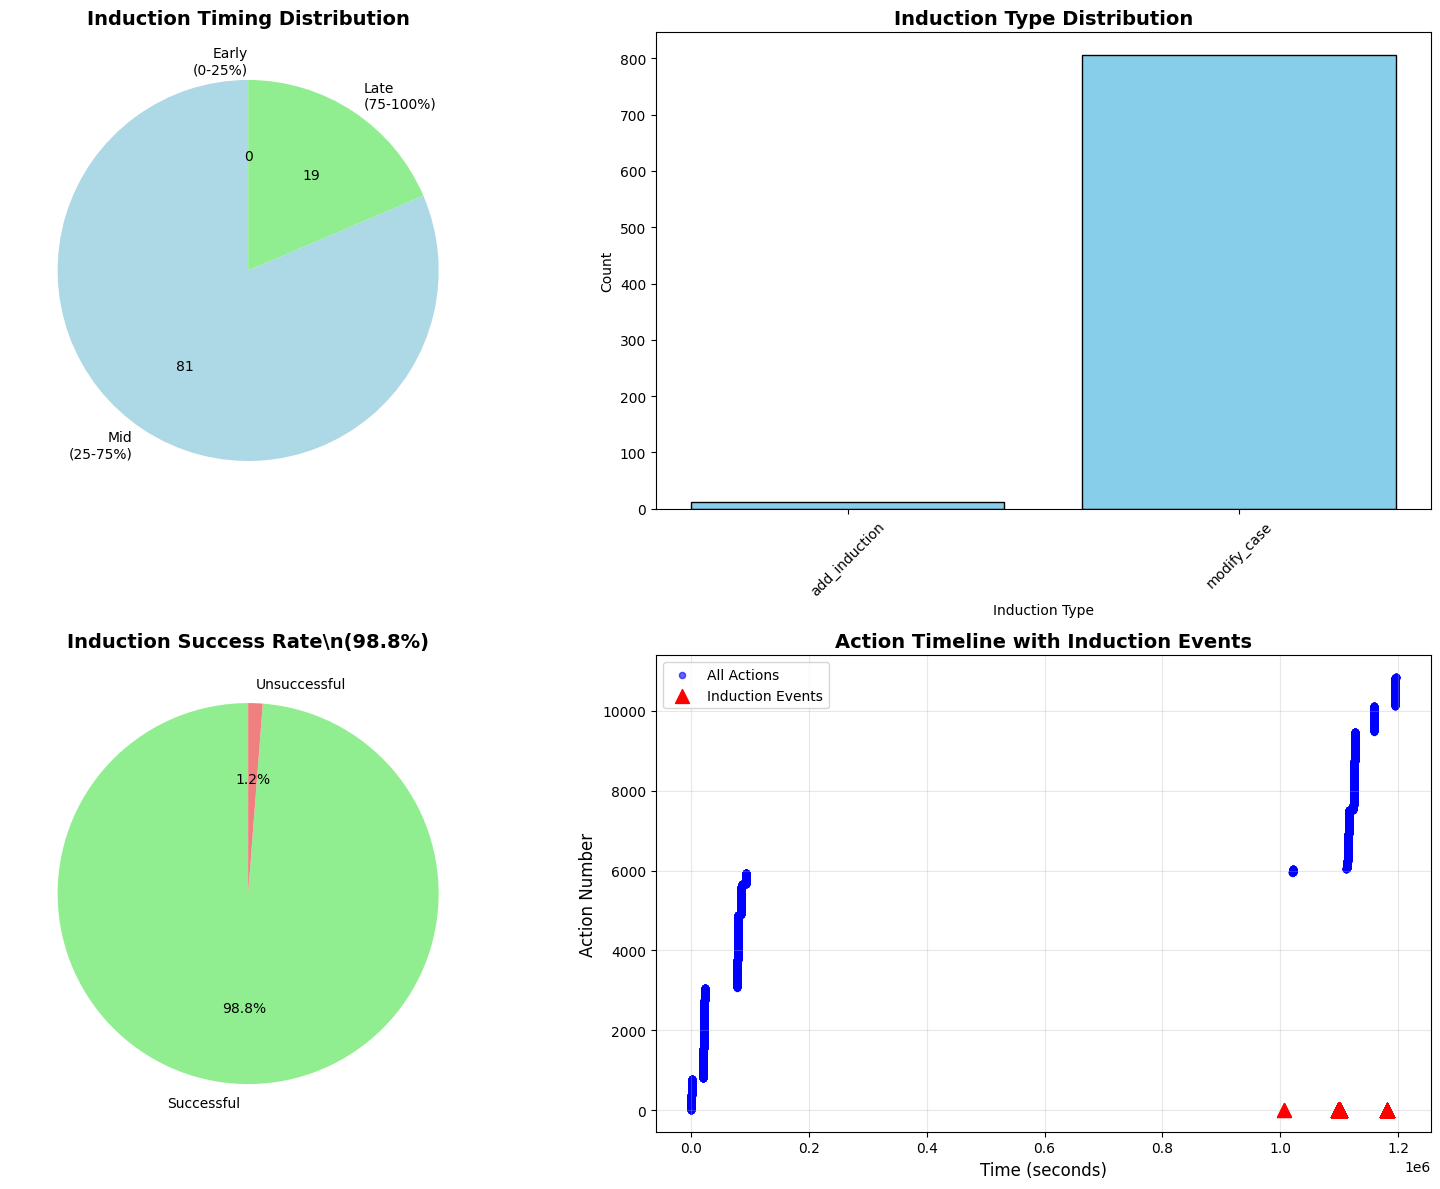

\nInduction Analysis Summary:
  Total induction events: 818
  Success rate: 98.8%
  Most common timing: mid_induction
  Most common type: modify_case


In [35]:
# Visualize induction patterns if any exist
if induction_analysis['total_induction_actions'] > 0:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Induction timing distribution
    timing_dist = timing_analysis['timing_distribution']
    labels = ['Early\n(0-25%)', 'Mid\n(25-75%)', 'Late\n(75-100%)']
    values = [timing_dist['early_induction'], timing_dist['mid_induction'], timing_dist['late_induction']]
    colors = ['lightcoral', 'lightblue', 'lightgreen']
    
    ax1.pie(values, labels=labels, colors=colors, autopct='%1.0f', startangle=90)
    ax1.set_title('Induction Timing Distribution', fontsize=14, fontweight='bold')
    
    # Plot 2: Induction type distribution
    type_dist = induction_analysis['induction_targets']['induction_type_distribution']
    if type_dist:
        ax2.bar(type_dist.keys(), type_dist.values(), color='skyblue', edgecolor='black')
        ax2.set_title('Induction Type Distribution', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Induction Type')
        ax2.set_ylabel('Count')
        ax2.tick_params(axis='x', rotation=45)
    else:
        ax2.text(0.5, 0.5, 'No induction types detected', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Induction Type Distribution', fontsize=14, fontweight='bold')
    
    # Plot 3: Success rate visualization
    success_data = induction_analysis['induction_success_patterns']
    if success_data['total_inductions'] > 0:
        success_labels = ['Successful', 'Unsuccessful']
        success_values = [success_data['successful_inductions'], 
                         success_data['total_inductions'] - success_data['successful_inductions']]
        success_colors = ['lightgreen', 'lightcoral']
        
        ax3.pie(success_values, labels=success_labels, colors=success_colors, 
               autopct='%1.1f%%', startangle=90)
        ax3.set_title(f'Induction Success Rate\\n({success_data["success_rate"]:.1%})', 
                     fontsize=14, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, 'No success data available', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Induction Success Rate', fontsize=14, fontweight='bold')
    
    # Plot 4: Action timeline with induction markers
    df_sorted = df.sort_values('datetime')
    times = (df_sorted['timestamp'] - df_sorted['timestamp'].min()) / 1000.0
    
    ax4.scatter(times, range(len(times)), alpha=0.6, s=20, c='blue', label='All Actions')
    
    # Mark induction events
    induction_times = []
    for event in induction_analysis['induction_events']:
        event_time = (event['timestamp'].timestamp() * 1000 - df_sorted['timestamp'].min()) / 1000.0
        induction_times.append(event_time)
    
    if induction_times:
        ax4.scatter(induction_times, [0] * len(induction_times), 
                   s=100, c='red', marker='^', label='Induction Events', zorder=5)
    
    ax4.set_xlabel('Time (seconds)', fontsize=12)
    ax4.set_ylabel('Action Number', fontsize=12)
    ax4.set_title('Action Timeline with Induction Events', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\\nInduction Analysis Summary:")
    print(f"  Total induction events: {induction_analysis['total_induction_actions']}")
    print(f"  Success rate: {success_data['success_rate']:.1%}")
    print(f"  Most common timing: {max(timing_dist.items(), key=lambda x: x[1])[0]}")
    if type_dist:
        print(f"  Most common type: {max(type_dist.items(), key=lambda x: x[1])[0]}")
else:
    print("No induction events found in this session - no visualizations to display.")


## Visualizations


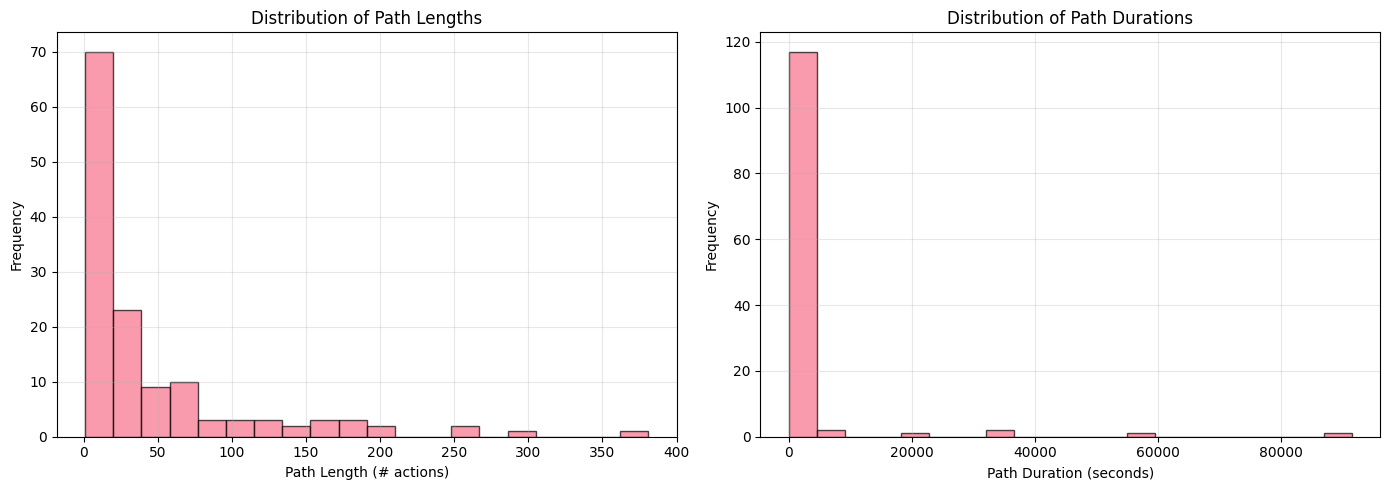

In [36]:
# Path length distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

path_lengths = [p.length for p in paths]
ax1.hist(path_lengths, bins=20, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Path Length (# actions)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Path Lengths')
ax1.grid(True, alpha=0.3)

# Path duration distribution
path_durations = [p.duration_seconds for p in paths if p.duration_seconds > 0]
ax2.hist(path_durations, bins=20, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Path Duration (seconds)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Path Durations')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


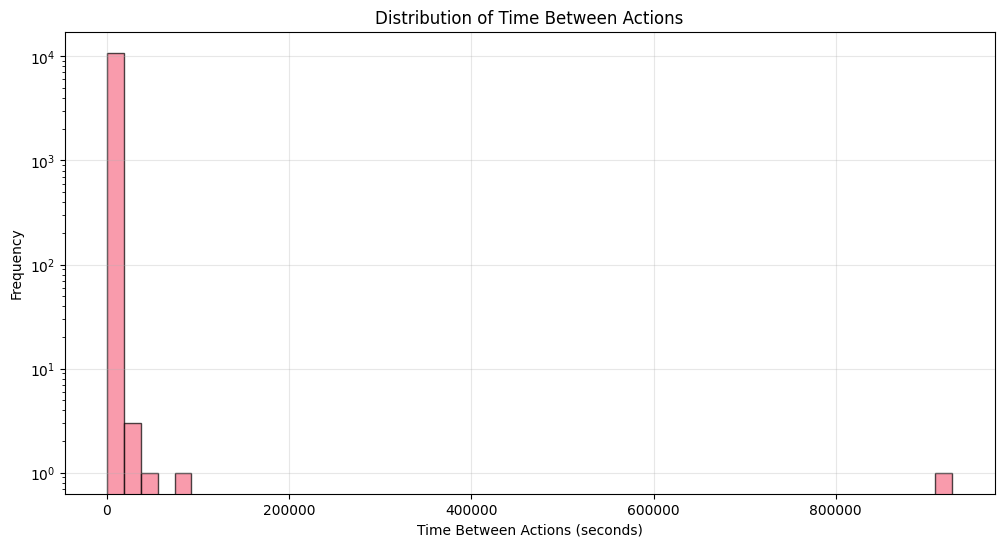

Time stats: mean=110.25s, median=0.18s


In [37]:
# Time between actions histogram
time_diffs = calculate_time_diffs(df)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(time_diffs, bins=50, alpha=0.7, edgecolor='black')
ax.set_xlabel('Time Between Actions (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Time Between Actions')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.show()

print(f"Time stats: mean={time_diffs.mean():.2f}s, median={time_diffs.median():.2f}s")


## Path Visualizations

Visualize action sequences as trees/graphs showing progression and backtracking


In [38]:
def visualize_all_paths(paths, title="All Action Paths", max_actions_per_path=100):
    """
    Visualize all paths together in a single graph.
    Each path is shown at a different vertical offset, creating a forest visualization.
    """
    if len(paths) == 0:
        print("No paths to visualize")
        return
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, min(len(paths), 10)))
    
    all_stats = []
    y_offset = 0
    y_spacing = 5  # Vertical space between paths
    
    for path_idx, path in enumerate(paths):
        if len(path.actions) == 0:
            continue
        
        actions_to_show = min(len(path.actions), max_actions_per_path)
        color = colors[path_idx % len(colors)]
        
        # Track position of each node in this path
        x_positions = []
        y_positions = []
        is_backtrack = []
        
        x = 0
        current_depth = 0
        
        for i in range(actions_to_show):
            action_str = str(path.actions[i]).lower()
            backtrack = any(kw in action_str for kw in ['undo', 'redo', 'back', 'revert', 'destruct'])
            is_backtrack.append(backtrack)
            
            if backtrack and current_depth > 0:
                current_depth -= 1
                x = current_depth
            else:
                x = current_depth
                current_depth += 1
            
            x_positions.append(x)
            y_positions.append(y_offset - i * 0.2)  # Compact vertical spacing
        
        # Draw connections
        for i in range(len(x_positions) - 1):
            line_color = 'red' if is_backtrack[i+1] else color
            alpha = 0.4 if is_backtrack[i+1] else 0.7
            ax.plot([x_positions[i], x_positions[i+1]], 
                   [y_positions[i], y_positions[i+1]], 
                   color=line_color, alpha=alpha, linewidth=1.5)
        
        # Draw nodes
        for i, (x, y) in enumerate(zip(x_positions, y_positions)):
            node_color = 'red' if is_backtrack[i] else color
            ax.scatter(x, y, s=50, c=[node_color], edgecolors='black', 
                      linewidth=0.5, zorder=3, alpha=0.8)
        
        # Label the path at its start
        ax.text(-0.5, y_positions[0], f'P{path_idx+1}', 
               fontsize=9, va='center', ha='right', weight='bold')
        
        # Store stats
        all_stats.append({
            'path_id': path_idx + 1,
            'length': len(path.actions),
            'max_depth': max(x_positions) + 1 if x_positions else 0,
            'backtracks': sum(is_backtrack)
        })
        
        y_offset -= (actions_to_show * 0.2 + y_spacing)
    
    ax.set_xlabel('Depth (→ = Forward, ← = Backtrack)', fontsize=12)
    ax.set_ylabel('Paths (time flows downward within each path)', fontsize=12)
    ax.set_title(f'{title}\\n{len(paths)} paths visualized', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', edgecolor='black', label='Forward Action', alpha=0.7),
        Patch(facecolor='red', edgecolor='black', label='Backtrack', alpha=0.7)
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nPath Summary:")
    for stat in all_stats:
        print(f"  Path {stat['path_id']}: {stat['length']} actions, "
              f"max depth {stat['max_depth']}, {stat['backtracks']} backtracks")
    
    total_actions = sum(s['length'] for s in all_stats)
    total_backtracks = sum(s['backtracks'] for s in all_stats)
    print(f"\nOverall: {total_actions} total actions, {total_backtracks} total backtracks")


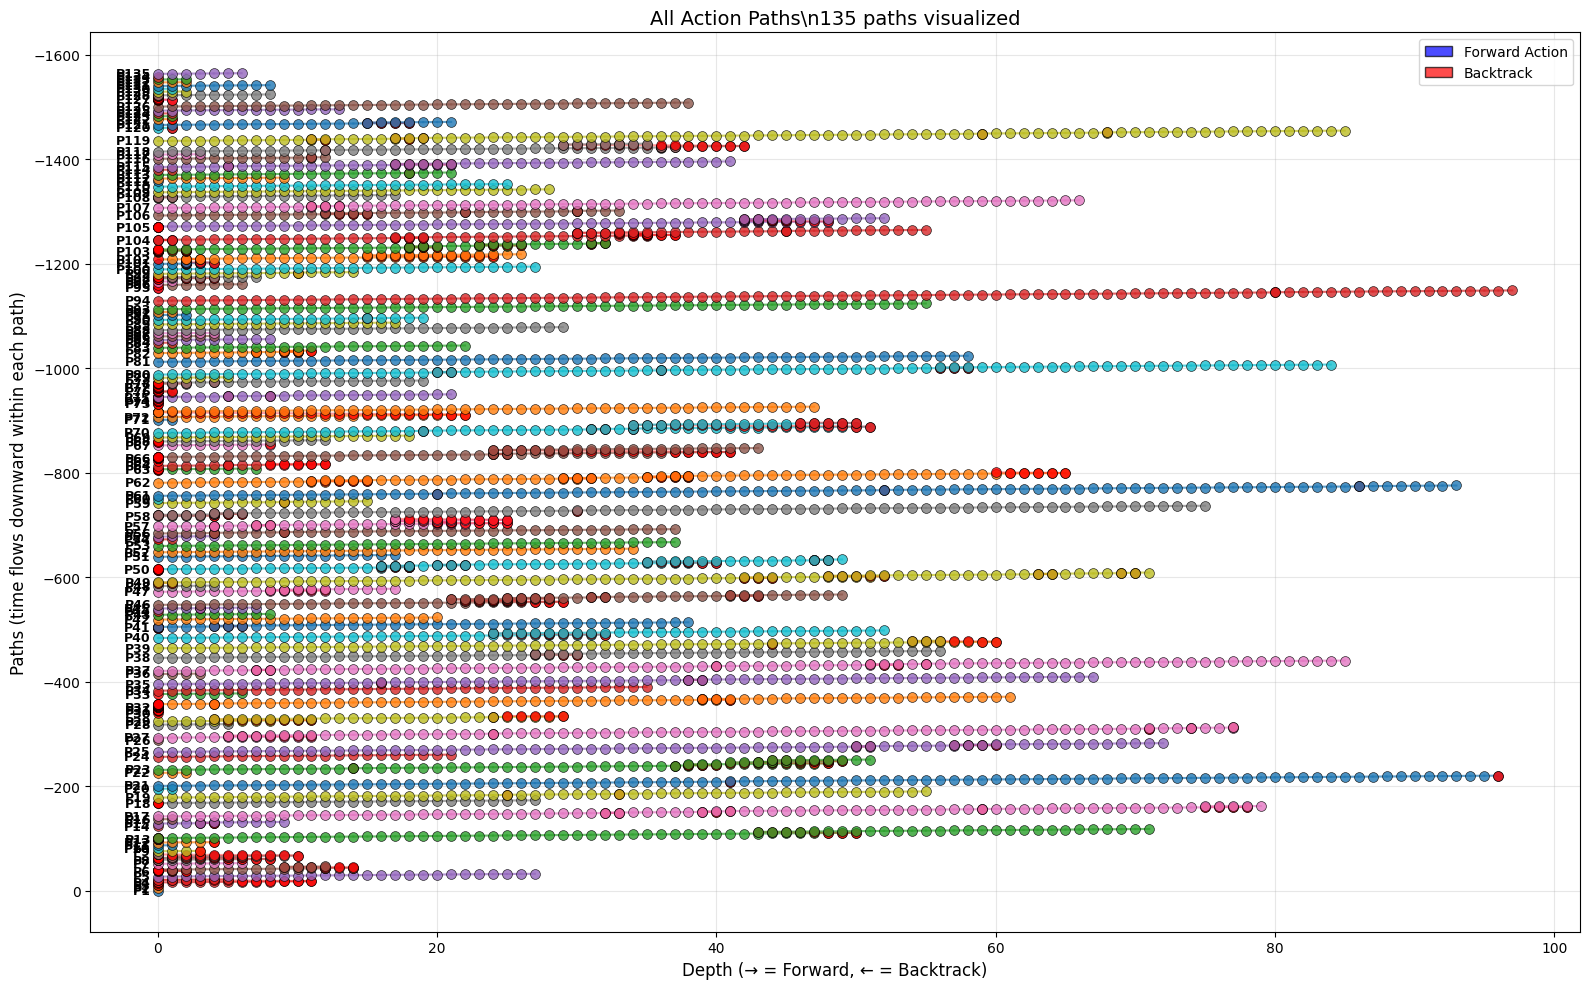


Path Summary:
  Path 1: 1 actions, max depth 1, 0 backtracks
  Path 2: 1 actions, max depth 1, 0 backtracks
  Path 3: 2 actions, max depth 1, 1 backtracks
  Path 4: 32 actions, max depth 12, 14 backtracks
  Path 5: 28 actions, max depth 28, 0 backtracks
  Path 6: 45 actions, max depth 15, 19 backtracks
  Path 7: 7 actions, max depth 7, 0 backtracks
  Path 8: 63 actions, max depth 11, 35 backtracks
  Path 9: 5 actions, max depth 4, 1 backtracks
  Path 10: 1 actions, max depth 1, 0 backtracks
  Path 11: 2 actions, max depth 2, 0 backtracks
  Path 12: 6 actions, max depth 5, 1 backtracks
  Path 13: 202 actions, max depth 72, 20 backtracks
  Path 14: 1 actions, max depth 1, 0 backtracks
  Path 15: 16 actions, max depth 10, 3 backtracks
  Path 16: 2 actions, max depth 2, 0 backtracks
  Path 17: 176 actions, max depth 80, 10 backtracks
  Path 18: 30 actions, max depth 28, 3 backtracks
  Path 19: 60 actions, max depth 56, 2 backtracks
  Path 20: 2 actions, max depth 2, 0 backtracks
  Path 21

In [39]:
# Visualize all paths together
if len(paths) > 0:
    visualize_all_paths(paths, "All Action Paths")



Visualizing 115 exploration paths together


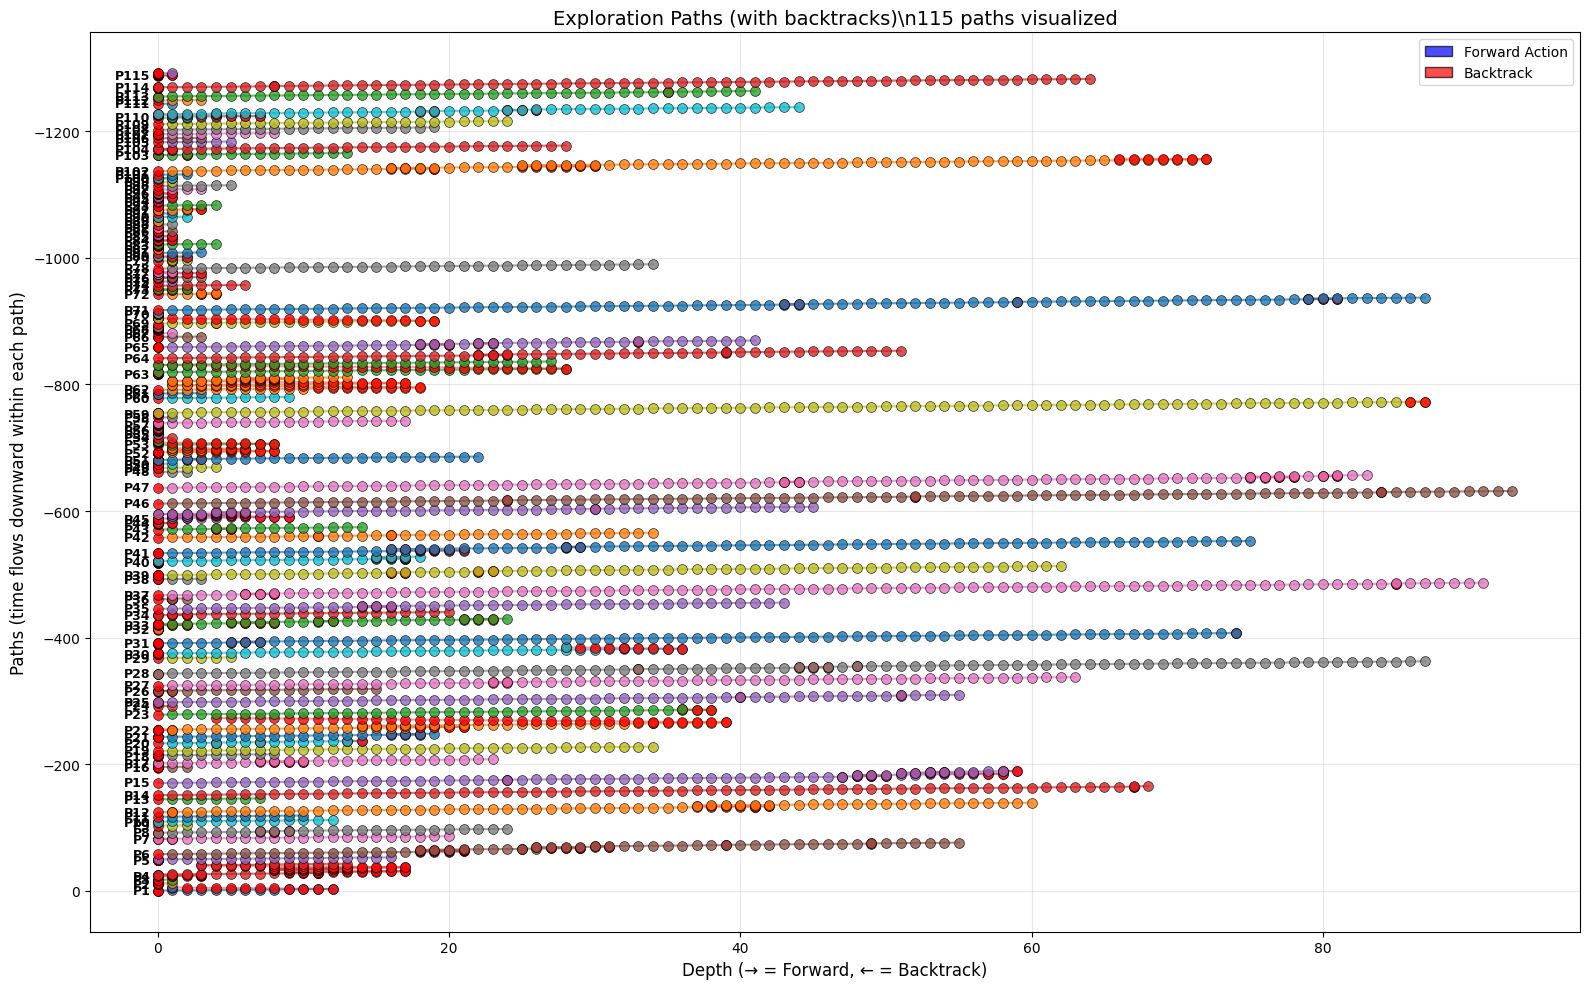


Path Summary:
  Path 1: 28 actions, max depth 13, 15 backtracks
  Path 2: 8 actions, max depth 2, 7 backtracks
  Path 3: 4 actions, max depth 2, 3 backtracks
  Path 4: 153 actions, max depth 18, 45 backtracks
  Path 5: 25 actions, max depth 17, 8 backtracks
  Path 6: 92 actions, max depth 56, 19 backtracks
  Path 7: 25 actions, max depth 21, 3 backtracks
  Path 8: 33 actions, max depth 25, 5 backtracks
  Path 9: 3 actions, max depth 3, 1 backtracks
  Path 10: 17 actions, max depth 13, 4 backtracks
  Path 11: 11 actions, max depth 11, 1 backtracks
  Path 12: 77 actions, max depth 61, 9 backtracks
  Path 13: 8 actions, max depth 8, 1 backtracks
  Path 14: 71 actions, max depth 69, 2 backtracks
  Path 15: 97 actions, max depth 60, 20 backtracks
  Path 16: 7 actions, max depth 3, 5 backtracks
  Path 17: 34 actions, max depth 24, 6 backtracks
  Path 18: 15 actions, max depth 9, 7 backtracks
  Path 19: 35 actions, max depth 35, 1 backtracks
  Path 20: 22 actions, max depth 15, 5 backtracks


In [40]:
# Visualize exploration paths together (those with backtracks)
if len(exploration_paths) > 0:
    print(f"\nVisualizing {len(exploration_paths)} exploration paths together")
    visualize_all_paths(exploration_paths, "Exploration Paths (with backtracks)")


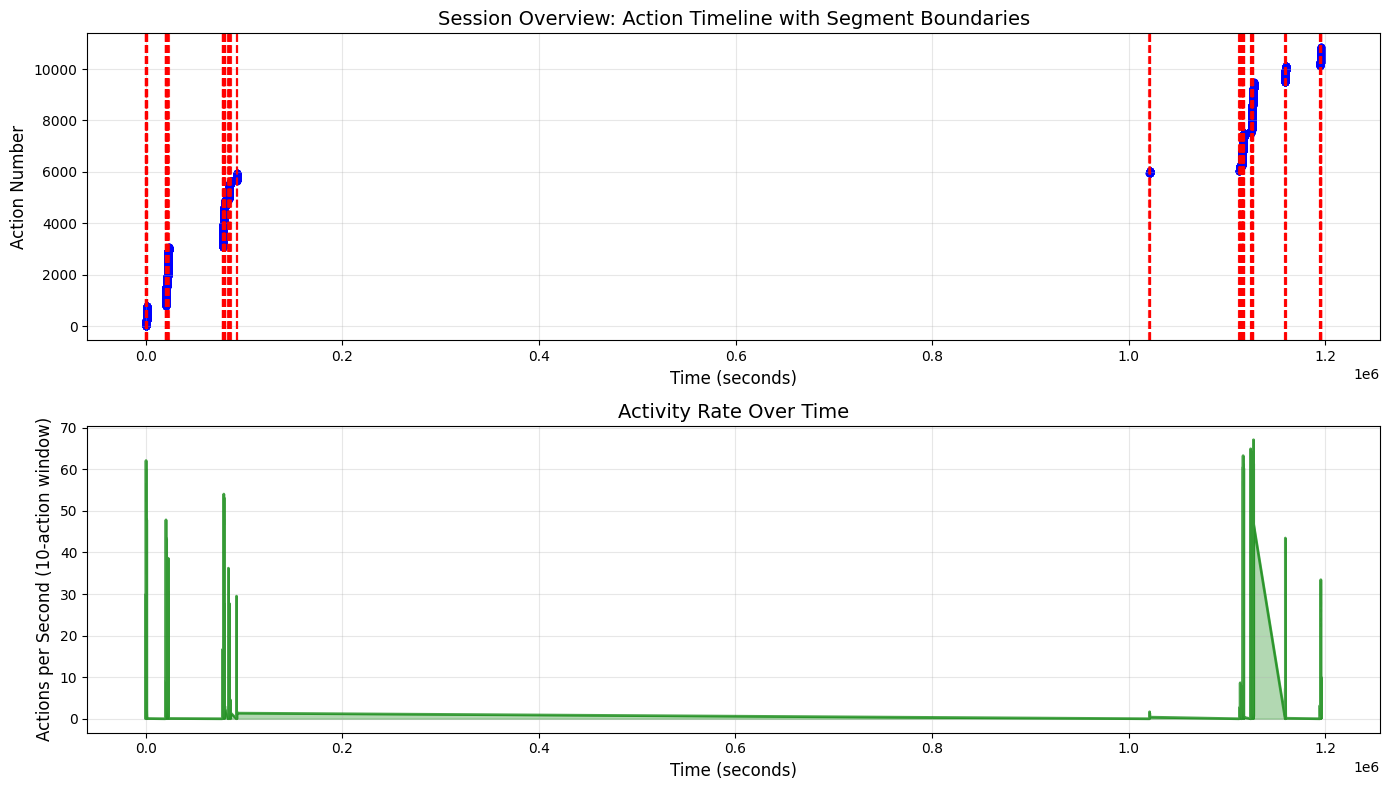

Session Overview Statistics:
  Total segments: 242
  Total duration: 1195815.0s
  Average activity rate: 0.01 actions/sec


In [41]:
def visualize_session_overview(df, segments):
    """
    Create an overview visualization of the entire session showing
    activity levels and segments.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot 1: Action timeline with segment boundaries
    df_sorted = df.sort_values('datetime')
    time_diffs = calculate_time_diffs(df)
    
    # Normalize timestamps to start at 0
    start_time = df_sorted['timestamp'].min()
    times = (df_sorted['timestamp'] - start_time) / 1000.0  # Convert to seconds
    
    ax1.scatter(times, range(len(times)), alpha=0.6, s=20, c='blue')
    
    # Mark segment boundaries
    for seg in segments:
        if seg['segment_id'] > 0:
            boundary_idx = seg['start_idx']
            if boundary_idx < len(times):
                boundary_time = times.iloc[boundary_idx]
                ax1.axvline(x=boundary_time, color='red', linestyle='--', alpha=0.5)
    
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel('Action Number', fontsize=12)
    ax1.set_title('Session Overview: Action Timeline with Segment Boundaries', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Activity rate over time (actions per second)
    window_size = 10
    rolling_rate = []
    rolling_times = []
    
    for i in range(window_size, len(times)):
        window_start = i - window_size
        time_span = times.iloc[i] - times.iloc[window_start]
        if time_span > 0:
            rate = window_size / time_span
            rolling_rate.append(rate)
            rolling_times.append(times.iloc[i])
    
    ax2.plot(rolling_times, rolling_rate, linewidth=2, color='green', alpha=0.7)
    ax2.fill_between(rolling_times, rolling_rate, alpha=0.3, color='green')
    ax2.set_xlabel('Time (seconds)', fontsize=12)
    ax2.set_ylabel('Actions per Second (10-action window)', fontsize=12)
    ax2.set_title('Activity Rate Over Time', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Session Overview Statistics:")
    print(f"  Total segments: {len(segments)}")
    print(f"  Total duration: {times.iloc[-1]:.1f}s")
    print(f"  Average activity rate: {len(df) / times.iloc[-1]:.2f} actions/sec")

# Create session overview
visualize_session_overview(df, segments)


## Multi-File Induction Analysis Comparison


In [42]:
# Compare induction patterns across multiple log files
if len(all_logs) > 1:
    print("=== MULTI-FILE INDUCTION COMPARISON ===")
    
    comparison_results = {}
    
    for filepath, df in all_logs.items():
        print(f"\n--- Analyzing {filepath} ---")
        
        # Get induction analysis for this file
        induction_analysis = find_induction_patterns(df)
        timing_analysis = analyze_induction_timing_patterns(df)
        progression_analysis = track_induction_progression(df)
        
        comparison_results[filepath] = {
            'induction_analysis': induction_analysis,
            'timing_analysis': timing_analysis,
            'progression_analysis': progression_analysis
        }
        
        print(f"Total induction actions: {induction_analysis['total_induction_actions']}")
        print(f"Session type: {induction_analysis.get('session_type', 'unknown')}")
        
        if induction_analysis['total_induction_actions'] > 0:
            print(f"Time to first induction: {induction_analysis['time_to_first_induction']:.1f}s")
            print(f"Success rate: {induction_analysis['induction_success_patterns']['success_rate']:.1%}")
            
            # Show induction types
            type_dist = induction_analysis['induction_targets']['induction_type_distribution']
            if type_dist:
                print(f"Induction types: {dict(type_dist)}")
        else:
            print("No induction events found")
    
    # Create comparison summary
    print(f"\n=== COMPARISON SUMMARY ===")
    for filepath, results in comparison_results.items():
        induction_count = results['induction_analysis']['total_induction_actions']
        session_type = results['induction_analysis'].get('session_type', 'unknown')
        print(f"{filepath}: {induction_count} inductions, {session_type} session")
        
        if induction_count > 0:
            success_rate = results['induction_analysis']['induction_success_patterns']['success_rate']
            print(f"  Success rate: {success_rate:.1%}")
            
            # Show timing distribution
            timing_dist = results['timing_analysis']['timing_distribution']
            print(f"  Timing: Early={timing_dist['early_induction']}, Mid={timing_dist['mid_induction']}, Late={timing_dist['late_induction']}")
else:
    print("Only one log file loaded - no comparison available")


=== MULTI-FILE INDUCTION COMPARISON ===

--- Analyzing a2_logs/submission_349549369.json ---
Total induction actions: 818
Session type: theorem_focused
Time to first induction: 1021308.0s
Success rate: 98.8%
Induction types: {'add_induction': 12, 'modify_case': 806}

--- Analyzing a2_logs/submission_349944161.json ---
Total induction actions: 615
Session type: implementation_focused
Time to first induction: 787153.6s
Success rate: 90.6%
Induction types: {'add_induction': 14, 'modify_case': 601}

=== COMPARISON SUMMARY ===
a2_logs/submission_349549369.json: 818 inductions, theorem_focused session
  Success rate: 98.8%
  Timing: Early=0, Mid=666, Late=152
a2_logs/submission_349944161.json: 615 inductions, implementation_focused session
  Success rate: 90.6%
  Timing: Early=0, Mid=0, Late=615


=== MULTI-FILE INDUCTION VISUALIZATION ===


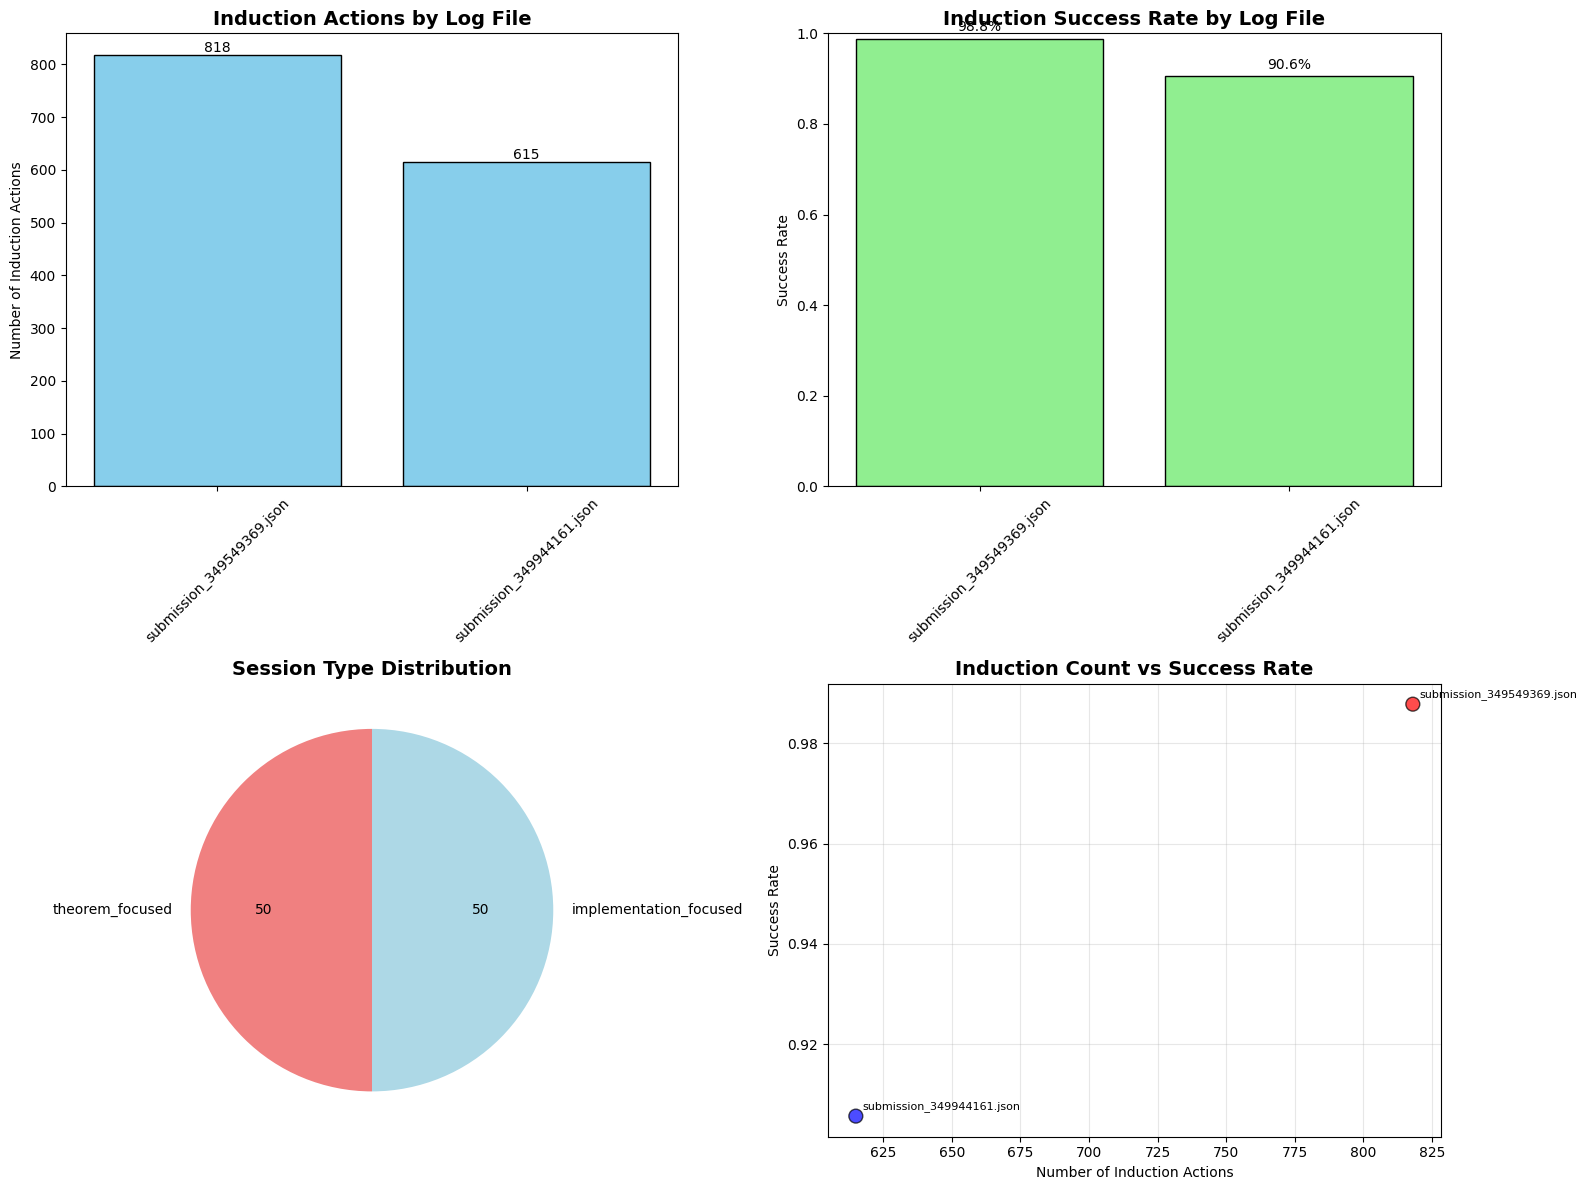


Summary Statistics:
  Total files analyzed: 2
  Total induction actions: 1433
  Average induction actions per file: 716.5
  Average success rate: 94.7%
  Files with inductions: 2


In [43]:
# Visualize comparison results if we have multiple files
if len(all_logs) > 1 and 'comparison_results' in locals():
    print("=== MULTI-FILE INDUCTION VISUALIZATION ===")
    
    # Prepare data for visualization
    file_names = []
    induction_counts = []
    success_rates = []
    session_types = []
    
    for filepath, results in comparison_results.items():
        file_names.append(filepath.split('/')[-1])  # Just filename
        induction_counts.append(results['induction_analysis']['total_induction_actions'])
        success_rates.append(results['induction_analysis']['induction_success_patterns']['success_rate'])
        session_types.append(results['induction_analysis'].get('session_type', 'unknown'))
    
    # Create comparison visualizations
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Induction counts by file
    bars1 = ax1.bar(file_names, induction_counts, color='skyblue', edgecolor='black')
    ax1.set_title('Induction Actions by Log File', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Induction Actions')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, count in zip(bars1, induction_counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                str(count), ha='center', va='bottom')
    
    # Plot 2: Success rates by file
    bars2 = ax2.bar(file_names, success_rates, color='lightgreen', edgecolor='black')
    ax2.set_title('Induction Success Rate by Log File', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Success Rate')
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis='x', rotation=45)
    
    # Add percentage labels on bars
    for bar, rate in zip(bars2, success_rates):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{rate:.1%}', ha='center', va='bottom')
    
    # Plot 3: Session type distribution
    session_type_counts = {}
    for st in session_types:
        session_type_counts[st] = session_type_counts.get(st, 0) + 1
    
    if session_type_counts:
        ax3.pie(session_type_counts.values(), labels=session_type_counts.keys(), 
               autopct='%1.0f', startangle=90, colors=['lightcoral', 'lightblue', 'lightgreen', 'lightyellow'])
        ax3.set_title('Session Type Distribution', fontsize=14, fontweight='bold')
    
    # Plot 4: Combined analysis
    # Create a scatter plot of induction count vs success rate
    colors = ['red' if st == 'theorem_focused' else 'blue' if st == 'implementation_focused' else 'green' 
              for st in session_types]
    
    ax4.scatter(induction_counts, success_rates, c=colors, s=100, alpha=0.7, edgecolors='black')
    ax4.set_xlabel('Number of Induction Actions')
    ax4.set_ylabel('Success Rate')
    ax4.set_title('Induction Count vs Success Rate', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    # Add file labels to points
    for i, (x, y, name) in enumerate(zip(induction_counts, success_rates, file_names)):
        ax4.annotate(name, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"  Total files analyzed: {len(file_names)}")
    print(f"  Total induction actions: {sum(induction_counts)}")
    print(f"  Average induction actions per file: {sum(induction_counts)/len(induction_counts):.1f}")
    print(f"  Average success rate: {sum(success_rates)/len(success_rates):.1%}")
    print(f"  Files with inductions: {sum(1 for count in induction_counts if count > 0)}")
    
else:
    print("No comparison data available for visualization")


## Analyzing Additional Log Files

The `a2_logs` directory contains many more student submission logs. Here's how to analyze them:


In [44]:
# Example: Analyze additional log files from a2_logs (different from the main analysis files)
import os

# List some available log files
a2_logs_dir = "a2_logs"
if os.path.exists(a2_logs_dir):
    log_files = [f for f in os.listdir(a2_logs_dir) if f.endswith('.json')]
    print(f"Found {len(log_files)} log files in {a2_logs_dir}")
    print("Sample files:", log_files[:5])
    
    # Analyze a few specific files (excluding the ones already used in main analysis)
    main_files = ["submission_349549369.json", "submission_349944161.json"]
    available_files = [f for f in log_files if f not in main_files]
    sample_files = available_files[:3]  # Take first 3 files not used in main analysis
    
    print(f"\n=== ANALYZING SAMPLE FILES ===")
    for filename in sample_files:
        filepath = os.path.join(a2_logs_dir, filename)
        try:
            df_sample = parser.parse_file(filepath)
            induction_analysis = find_induction_patterns(df_sample)
            
            print(f"\n{filename}:")
            print(f"  Actions: {len(df_sample)}")
            print(f"  Duration: {(df_sample['datetime'].max() - df_sample['datetime'].min()).total_seconds():.1f}s")
            print(f"  Induction actions: {induction_analysis['total_induction_actions']}")
            print(f"  Session type: {induction_analysis.get('session_type', 'unknown')}")
            
            if induction_analysis['total_induction_actions'] > 0:
                success_rate = induction_analysis['induction_success_patterns']['success_rate']
                print(f"  Success rate: {success_rate:.1%}")
                
                # Show some induction details
                events = induction_analysis['induction_events']
                if events:
                    print(f"  First induction: {events[0]['timestamp']}")
                    context = events[0].get('context', {})
                    print(f"  Induction type: {context.get('induction_type', 'unknown')}")
                    print(f"  Target term: {context.get('target_term', 'unknown')}")
        except Exception as e:
            print(f"Error analyzing {filename}: {e}")
else:
    print(f"Directory {a2_logs_dir} not found")


Found 25 log files in a2_logs
Sample files: ['submission_349980734.json', 'submission_349549369.json', 'submission_348406434.json', 'submission_350046114.json', 'submission_349144175.json']

=== ANALYZING SAMPLE FILES ===

submission_349980734.json:
  Actions: 10986
  Duration: 1092681.3s
  Induction actions: 887
  Session type: theorem_focused
  Success rate: 92.9%
  First induction: 2025-09-21 23:34:05.764000
  Induction type: add_induction
  Target term: None

submission_348406434.json:
  Actions: 20929
  Duration: 1147085.2s
  Induction actions: 1446
  Session type: theorem_focused
  Success rate: 45.8%
  First induction: 2025-09-17 13:38:35.633000
  Induction type: add_induction
  Target term: None

submission_350046114.json:
  Actions: 4092
  Duration: 79626.2s
  Induction actions: 985
  Session type: theorem_focused
  Success rate: 95.1%
  First induction: 2025-09-21 20:44:15.027000
  Induction type: add_induction
  Target term: None


## Research Usage Instructions

This notebook provides comprehensive analysis of Hazel student interaction logs with a focus on induction patterns. Here's how to use it for research:

### Key Features:
1. **Induction Detection**: Automatically identifies when students perform induction actions
2. **Success Analysis**: Tracks whether induction attempts lead to progress or backtracking
3. **Timing Analysis**: Analyzes when induction occurs in the session (early, mid, late)
4. **Session Classification**: Categorizes sessions as theorem-focused, implementation-focused, or mixed
5. **Multi-file Comparison**: Compare patterns across multiple student submissions

### Research Questions This Addresses:
- **When do students attempt induction?** (timing analysis)
- **What terms do they induct over?** (target term analysis)
- **How successful are their induction attempts?** (success rate analysis)
- **What actions precede and follow induction?** (context analysis)
- **How do different students approach induction?** (comparative analysis)

### To Analyze Your Own Logs:
1. Replace the `log_files` list in cell 3 with your log file paths
2. Run the notebook to get comprehensive analysis
3. Use the multi-file comparison features to analyze multiple submissions
4. Export results for further statistical analysis

### Customization:
- Modify `induction_action_patterns` in `path_extractor.py` to detect different action types
- Adjust success/failure indicators based on your specific research needs
- Add new analysis functions to explore additional patterns
